In [16]:
import os
import tifffile
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from skimage.draw import polygon
from matplotlib.collections import LineCollection
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
def detect_fluorescence_bursts_by_group(
    df: pd.DataFrame,
    fluor_col = 'intensity_mean_fluor',
    rolling_window_size: int = 6,
    std_dev_threshold: float = 2
) -> pd.DataFrame:
    """
    Detects fluorescence bursts for each unique experiment, FOV, and trench.

    Args:
        df (pd.DataFrame): The input DataFrame with 'experiment_name', 'FOV',
                           'trench_id', 'time_min', and 'mean_fluorescence' columns.
        rolling_window_size (int): The window size for the rolling filters
                                   (in number of time frames).
        std_dev_threshold (float): The number of standard deviations above the
                                   mean to be considered a significant burst.

    Returns:
        pd.DataFrame: The original DataFrame with new columns for burst detection.
    """
    processed_df_list = []

    # Group the DataFrame by the specified columns
    group_cols = ['gene', 'experiment_name', 'FOV']
    grouped_data = df.groupby(group_cols)

    for name, group in grouped_data:
        # Sort the group by time_frame to ensure rolling windows work correctly
        group = group.sort_values(by='time_frame')

        # Step 1: Baseline Subtraction (Local Baseline)
        group['local_min'] = group[fluor_col].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).min()
        
        group['normalized_fluorescence'] = group[fluor_col] - group['local_min']
        group['normalized_fluorescence'] = group['normalized_fluorescence'].clip(lower=0)

        # Step 2: Local Peak Detection
        group['local_max'] = group['normalized_fluorescence'].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).max()
        
        group['is_local_peak'] = (group['normalized_fluorescence'] == group['local_max'])

        # Step 3: Statistical Thresholding
        std_dev = group['normalized_fluorescence'].std()
        mean_signal = group['normalized_fluorescence'].mean()
        
        threshold = mean_signal + (std_dev_threshold * std_dev)

        group['is_burst'] = (group['is_local_peak']) & (group['normalized_fluorescence'] > threshold)

        processed_df_list.append(group)

    result_df = pd.concat(processed_df_list).reset_index(drop=True)
    
    # Remove temporary columns
    result_df = result_df.drop(columns=['local_min', 'local_max', 'is_local_peak'])

    return result_df

In [4]:
strain_exp_dict = {# need araB gitg61/CL08 lineage tracing CL008_giTG068_072925 pos 0-10 is CL08 # don't see fluor signal
                  # need murQ gitg67 lineage tracing potenitally DUMM_giTG068_067_061825 or DUMM_giTG63_giTG67_Glucose_121724_1 pos 6-9

                  'chpS':{'DUMM_giTG62_Glucose_012925': ['005']},  #need lineage tracing, Nora working on it
                  'baeS':{'DUMM_giTG66_Glucose_012325': ['003']},  # need to find new exp, lineage tracing is bad on this one
                  'lacZ':{'DUMM_giTG059_noKan_Glucose_031125': ['004'],
                         'DUMM_giTG059_060_061125': ['008']},
                  'gfcE': {'DUMM_giTG064_Glucose_022625': ['001', '015']},
                  'gldA': {'DUMM_giTG69_Glucose_013025': ['007']},
                  'alkA': {'DUMM_giTG068_063_061725_v2': ['000'],
                           'DUMM_giTG63_giTG67_Glucose_121724_1_v2': ['006']},
                  'mazF': {'DUMM_giTG059_060_061125': ['015']}, # constitutive
                  'hupA':{'DUMM_giTG068_052925': ['005'], 
                          'DUMM_giTG068_063_061725': ['012']} # constitutive
                  }

In [70]:
minutes_interval = {'DUMM_giTG62_Glucose_012925':5,
'DUMM_giTG66_Glucose_012325':5,
'DUMM_giTG059_noKan_Glucose_031125':5,
'DUMM_giTG059_060_061125':10,
'DUMM_giTG064_Glucose_022625':5,
'DUMM_giTG69_Glucose_013025':5,
'DUMM_giTG068_063_061725_v2':10,
'DUMM_giTG63_giTG67_Glucose_121724_1_v2':5,
'DUMM_giTG059_060_061125':10,
'DUMM_giTG068_052925':5,
'DUMM_giTG068_063_061725':10
}

In [5]:
tracked_all_cells_filename = f'/Users/noravivancogonzalez/Documents/DuMM_image_analysis/20250829_tracked_all_cell_data.pkl'
all_lineages_df = pd.read_pickle(tracked_all_cells_filename)

all_lineages_df['gene'] = None
for gene, exps_fov in strain_exp_dict.items():
    for exp_view, fovs in exps_fov.items():
        print(exp_view)
        mask = all_lineages_df['FOV'].isin(fovs) & (all_lineages_df['experiment_name'] == exp_view)
        all_lineages_df.loc[mask, 'gene'] = gene
        
bursts_all_lineages_df = detect_fluorescence_bursts_by_group(all_lineages_df,
                                                            fluor_col = 'intensity_mean_fluor',
                                                            rolling_window_size = 10,
                                                            std_dev_threshold = 3)
counts_per_lineage = bursts_all_lineages_df[~bursts_all_lineages_df['ground_truth_lineage'].isna()].groupby(['gene', 'experiment_name', 'FOV', 'trench_id', 'ground_truth_lineage']).size()

time_frames_per_avg_cell_cycle = counts_per_lineage.groupby(['gene', 'experiment_name']).mean().reset_index().rename(columns={0: 'average_frame_count'})
# First, calculate the number of peaks and unique cells for each gene/experiment combo.
grouped_data = bursts_all_lineages_df.groupby(['gene', 'experiment_name']).agg(
    num_peaks=('is_burst', 'sum'),  # Summing boolean 'is_burst' counts the True values
    num_cell_images=('node_id', pd.Series.nunique)
).reset_index()

# Second, merge this with the cell cycle length data
peak_freq_df = pd.merge(grouped_data, time_frames_per_avg_cell_cycle,
                        on=['gene', 'experiment_name'])
# Third, perform the final calculation
peak_freq_df['peak_frequency'] = (peak_freq_df['num_peaks'] / peak_freq_df['num_cell_images']) * peak_freq_df['average_frame_count']
avg_peak_freq_per_gene = peak_freq_df.groupby('gene')['peak_frequency'].mean().reset_index()

DUMM_giTG62_Glucose_012925
DUMM_giTG66_Glucose_012325
DUMM_giTG059_noKan_Glucose_031125
DUMM_giTG059_060_061125
DUMM_giTG064_Glucose_022625
DUMM_giTG69_Glucose_013025
DUMM_giTG068_063_061725_v2
DUMM_giTG63_giTG67_Glucose_121724_1_v2
DUMM_giTG059_060_061125
DUMM_giTG068_052925
DUMM_giTG068_063_061725


In [85]:
cols_use = ['gene', 'experiment_name', 'FOV', 'trench_id', 'predicted_lineage']
bursts_all_lineages_df['subgen'] = bursts_all_lineages_df.groupby(cols_use)['is_burst'].transform('any')

In [81]:
for gene in bursts_all_lineages_df['gene'].unique():
    print(gene)
    print(bursts_all_lineages_df['intensity_max_fluor'][bursts_all_lineages_df['gene'] == gene].describe())

baeS
count    864.000000
mean     302.672455
std      174.259216
min        6.000000
25%      189.750000
50%      299.000000
75%      402.000000
max      994.000000
Name: intensity_max_fluor, dtype: float64
chpS
count    3684.000000
mean       48.725029
std        14.925432
min        15.000000
25%        39.000000
50%        47.000000
75%        57.000000
max       128.000000
Name: intensity_max_fluor, dtype: float64
gfcE
count    4722.000000
mean       25.947056
std         7.526311
min         7.000000
25%        21.000000
50%        25.000000
75%        30.000000
max        90.000000
Name: intensity_max_fluor, dtype: float64
gldA
count    2232.000000
mean       28.871864
std         8.384458
min        11.000000
25%        23.000000
50%        28.000000
75%        33.000000
max        80.000000
Name: intensity_max_fluor, dtype: float64
hupA
count    2085.000000
mean      711.841248
std       213.171249
min       156.000000
25%       558.000000
50%       702.000000
75%       833.000

In [118]:
mask_baseline_exp = (bursts_all_lineages_df['intensity_max_fluor']> 60) & (~bursts_all_lineages_df['subgen'])
bursts_all_lineages_df['subgen'][mask_baseline_exp] = True

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_39499/4147307789.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bursts_all_lineages_df['subgen'][mask_baseline_exp] = True
/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipyke

In [119]:
bursts_all_lineages_df['time_interval_minutes'] = bursts_all_lineages_df['experiment_name'].map(minutes_interval)
bursts_all_lineages_df['time_minutes'] = bursts_all_lineages_df['time_interval_minutes'] * bursts_all_lineages_df['time_frame']

In [120]:
cols_use = ['gene', 'experiment_name', 'FOV', 'trench_id', 'predicted_lineage']
idx = bursts_all_lineages_df.groupby(cols_use)['time_minutes'].idxmin()

In [121]:
cell_first_appearance_df = bursts_all_lineages_df.loc[idx]
cell_first_appearance_df['mother_ids'] = cell_first_appearance_df['predicted_lineage'].str.split('.').str[0]

In [122]:
cells_sorted = cell_first_appearance_df.sort_values(
    by=['gene', 'experiment_name', 'FOV', 'trench_id', 'mother_ids', 'time_minutes'],
    ascending=True
).reset_index(drop=True)

In [147]:
cells_sorted.groupby('gene').count().iloc[:, 0]

gene
baeS     514
chpS     979
gfcE    1308
gldA     571
hupA     737
lacZ     965
mazF      59
Name: label, dtype: int64

In [123]:
def calculate_gaps_exp_experimental(df: pd.DataFrame) -> dict:
    """
    Calculates the length of consecutive runs of 'subgen' == False (non-expression)
    that are bounded by 'subgen' == True (expression) cells, allowing gaps
    that start at the first cell or end at the last cell of the gene's sequence.

    Args:
        df (pd.DataFrame): DataFrame with 'gene', 'subgen' columns.
                           Rows are expected to be ordered chronologically.

    Returns:
        dict: A dictionary where keys are gene names and values are lists of
              the lengths (in cells/rows) of the non-expression gaps found.
    """
    gene_non_expression_gaps = {}

    if df.empty:
        return {}

    grouped = df.groupby('gene')

    for gene, gene_df in grouped:
        # Get the first and last index of the current gene's sequence
        first_index = gene_df.index[0]
        last_index = gene_df.index[-1]

        # Invert 'subgen' to treat non-expression (False) as True for RLE grouping
        is_non_expression = (gene_df['subgen'] == False)

        # 1. Identify where a run of non-expression starts
        run_starts = is_non_expression & (~is_non_expression.shift(1).fillna(False))

        # 2. Assign a unique ID to each consecutive run and calculate run lengths
        run_id = run_starts.cumsum()
        non_expression_groups = run_id[is_non_expression]

        if not non_expression_groups.empty:
            non_expression_groups.name = 'run_id'
            gap_lengths_df = non_expression_groups.groupby(non_expression_groups).size().reset_index(name='length')

            # 3. Get the start and end index of each run
            run_start_indices = non_expression_groups.index.to_series().groupby(non_expression_groups).first()
            run_end_indices = non_expression_groups.index.to_series().groupby(non_expression_groups).last()

            gap_lengths_df['start_index'] = gap_lengths_df['run_id'].map(run_start_indices)
            gap_lengths_df['end_index'] = gap_lengths_df['run_id'].map(run_end_indices)

            # 4. Apply the fully inclusive boundary conditions:

            # Condition A (Precursor Check): Preceded by Expression OR Starts at First Index
            preceded_by_exp = (gene_df['subgen'].shift(1).loc[gap_lengths_df['start_index']] == True).fillna(False).values
            starts_at_first = (gap_lengths_df['start_index'] == first_index).values
            preceded_ok = preceded_by_exp | starts_at_first

            # Condition B (Successor Check): Followed by Expression OR Ends at Last Index
            followed_by_exp = (gene_df['subgen'].shift(-1).loc[gap_lengths_df['end_index']] == True).fillna(False).values
            ends_at_last = (gap_lengths_df['end_index'] == last_index).values
            followed_ok = followed_by_exp | ends_at_last

            # 5. Final Valid Gaps: (Preceded OK) AND (Followed OK)
            valid_gaps = gap_lengths_df[preceded_ok & followed_ok]

            gene_non_expression_gaps[gene] = valid_gaps['length'].tolist()
        else:
            gene_non_expression_gaps[gene] = []

    return gene_non_expression_gaps

In [124]:
results = calculate_gaps_exp_experimental(cells_sorted)

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_39499/1512737563.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  run_starts = is_non_expression & (~is_non_expression.shift(1).fillna(False))
/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_39499/1512737563.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  run_starts = is_non_expression & (~is_non_expression.shift(1).fillna(False))
/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_39499/1512737563.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill

In [141]:
def plot_average_gaps(protein_gaps_dict):
    """Calculates and plots the average gap lengths."""
    average_gaps = {}
    for protein, gaps in protein_gaps_dict.items():
        average = np.mean(gaps) if gaps else 0.0
        average_gaps[protein] = average

    df_avg = pd.DataFrame.from_dict(
        average_gaps, 
        orient='index', 
        columns=['Average Gap Length']
    ).sort_values(by='Average Gap Length', ascending=False)
    custom_order = ['lacZ', 'gldA', 'araB', 'murQ', 'alkA', 'gfcE', 'chpS', 'baeS', 'mazF', 'hupA']

    df_avg_ordered = df_avg.reindex(custom_order)

    plt.figure(figsize=(6, 6))
    bars = plt.bar(
        df_avg.index, 
        df_avg['Average Gap Length'],
        color='slateblue' 
    )

    plt.xlabel('Gene', fontsize=20)
    plt.ylabel('Average gap in expression \n (# generations)', fontsize=20)
    plt.xticks(rotation=45, fontsize=20)
    plt.yticks(fontsize=20)
    ax = plt.gca() 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

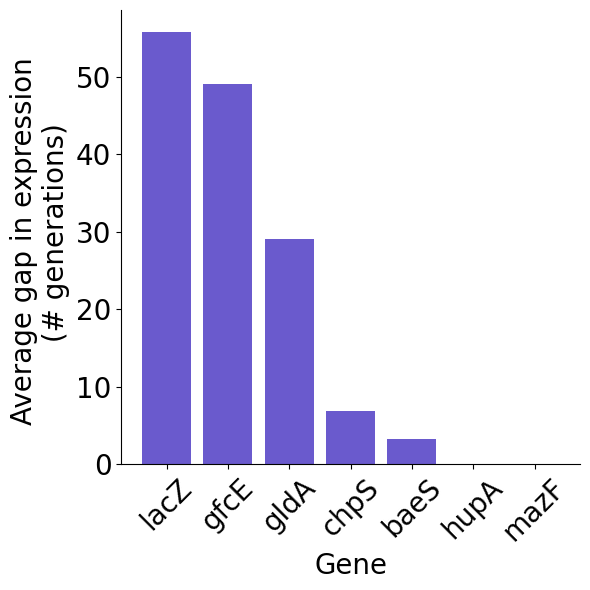

In [142]:
plot_average_gaps(results)